# Exploration approfondie de la base d'apprentissage

L'objectif de cette étape est de réaliser une **analyse exploratoire des données** afin d'extraire les premières tendances et de comprendre la structure de nos données.

> L'ensemble de l'EDA est mené **exclusivement sur le jeu d'entraînement (`train`)**. 
> Ce choix garantit l'absence totale de fuite d'information (*data leakage*) vis-à-vis des ensembles de validation et de test. Toutes les décisions de prétraitement (imputation des valeurs manquantes, encodage, normalisation) et de *feature engineering* découleront uniquement des statistiques observées sur ce jeu de données.

Nous allons analyser la distribution des variables, identifier d'éventuelles anomalies ou valeurs manquantes, et étudier les relations entre les variables explicatives et la cible.

## Partie A : Import de fonctions utiles à l'exploration de la base d'apprentissage

In [ ]:
# Importation des packages nécessaires

import pandas as pd
import sys
import os
import warnings
import pingouin as pg

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

## Partie B : Le traitement et l'analyse du jeu d'entraînement

### B1 : Configuration initiale

In [ ]:
# Paramètres fixes

FILE_PATH = "../data_finale/train.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

### B2 : 

In [ ]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 127
Variables catégorielles: 4


Analyse des valeurs manquantes
                     nb_missing    pct
xg_buildup                 4255  57.47
xa                         4255  57.47
Subs_Mn/Sub                1092  14.75
Team Success_On-Off          57   0.77
Team Success_PPM              5   0.07
height_in_cm                  2   0.03
nation                        1   0.01
xg                            1   0.01

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


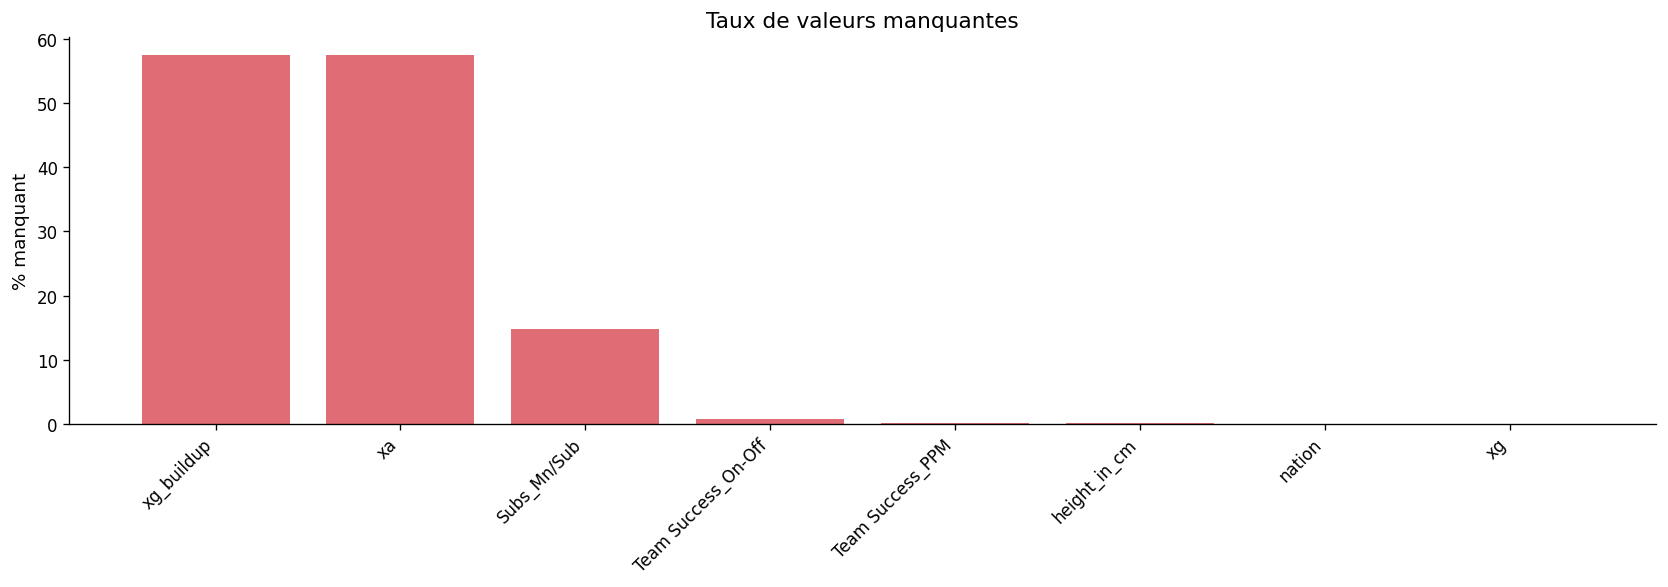

In [ ]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          7,404
mean      10,844,760
std       15,537,143
min           50,000
25%        2,000,000
50%        5,000,000
75%       14,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.24
Kurtosis : 15.64

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


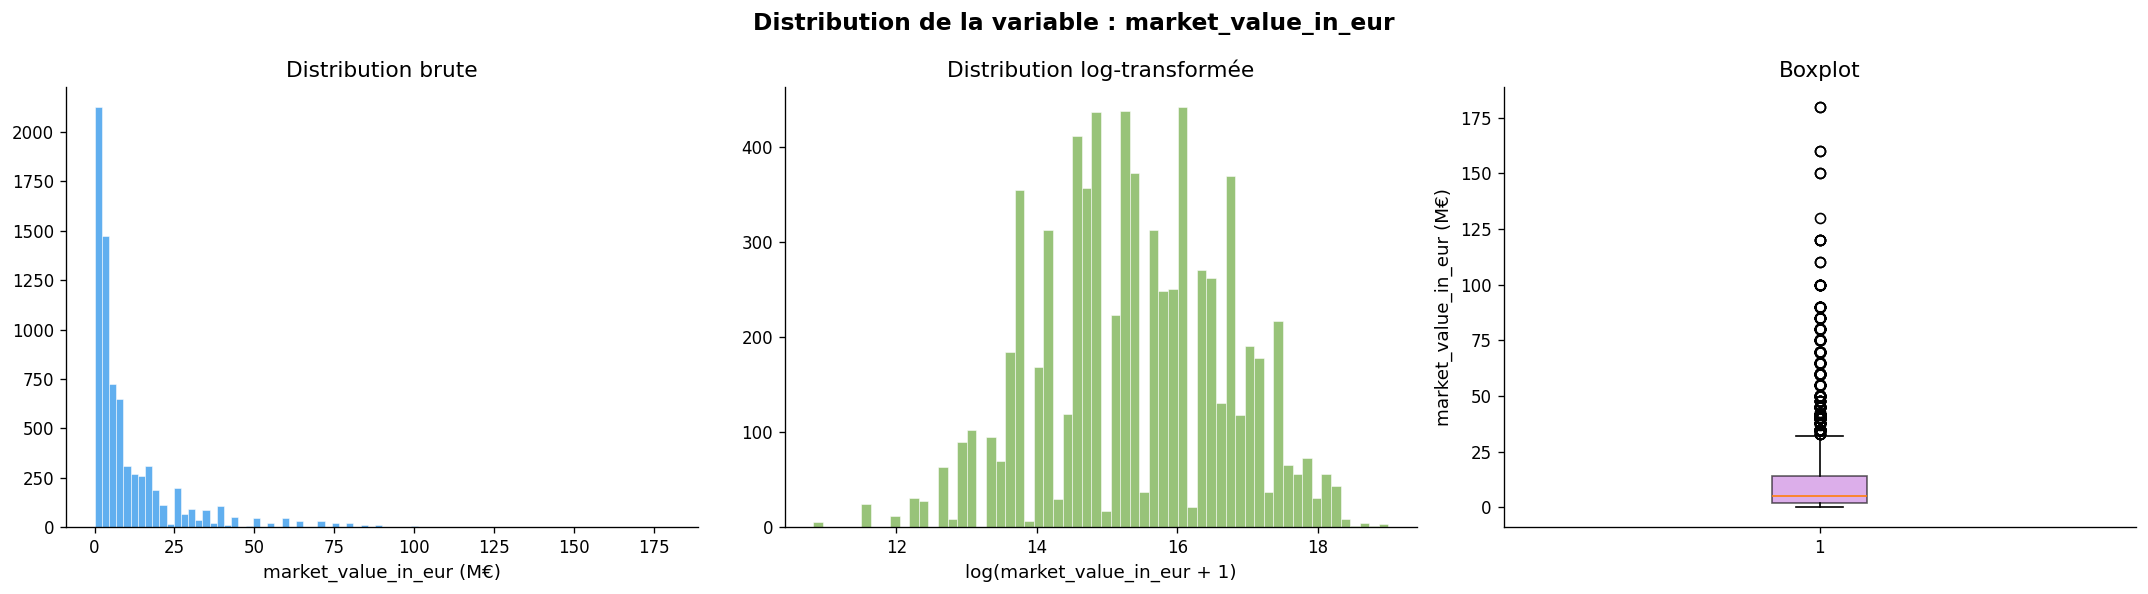

In [ ]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


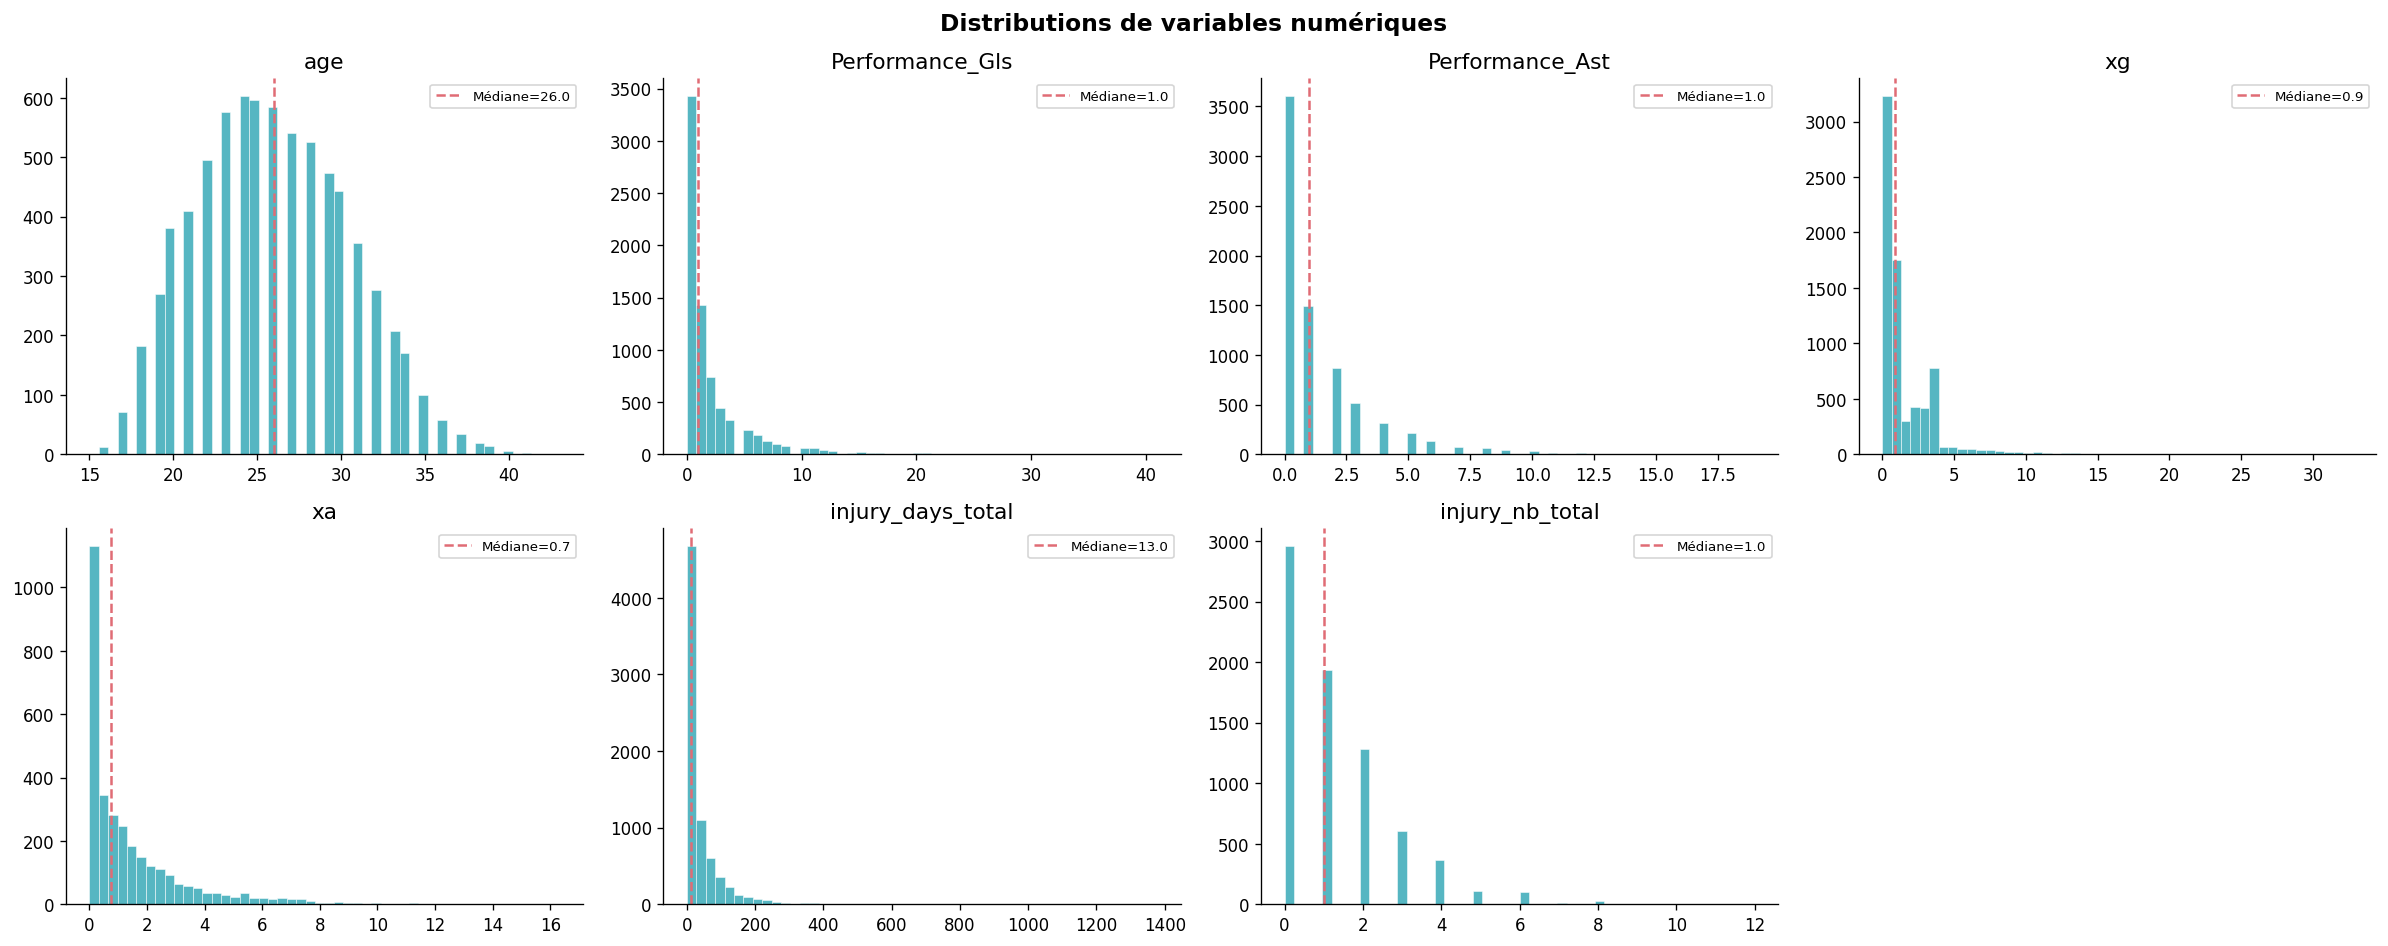

In [ ]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           1563
FRA-Ligue 1           1534
ESP-La Liga           1518
ENG-Premier League    1448
GER-Bundesliga        1341

players_top_nations.png sauvegardé


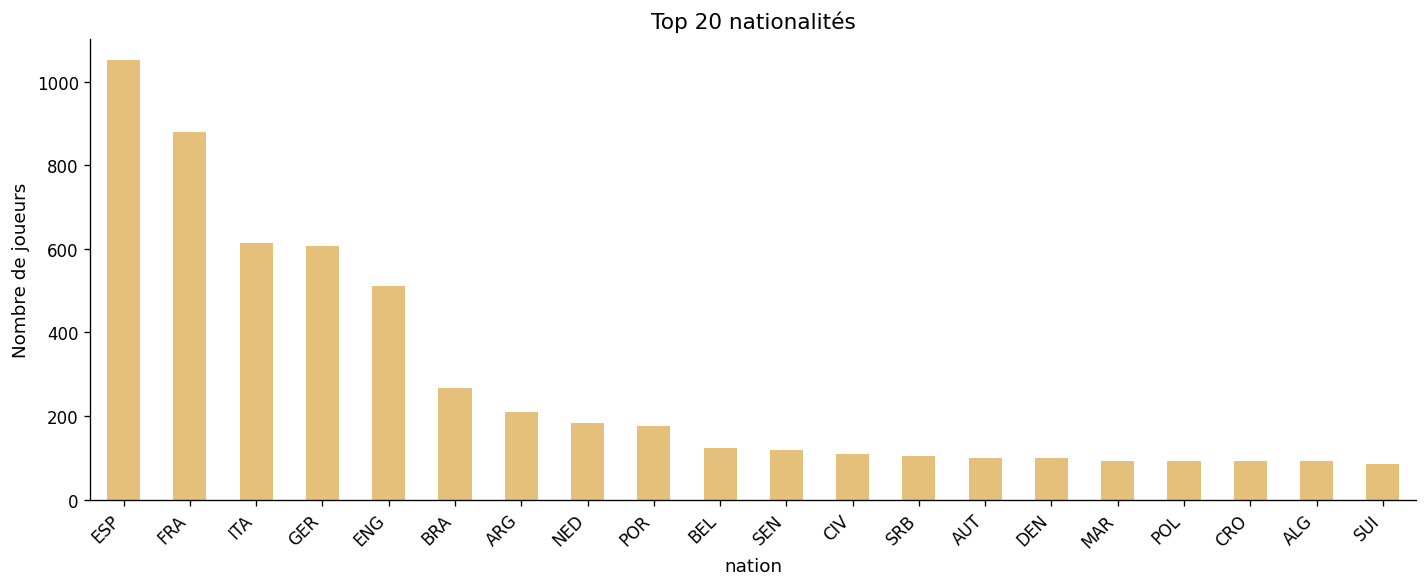

league.png sauvegardé


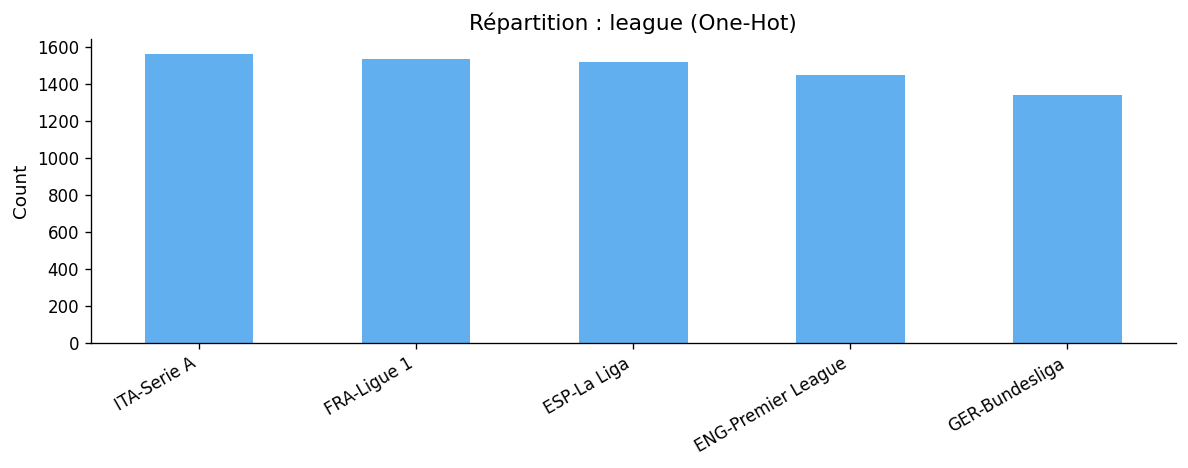

vm_par_league.png sauvegardé


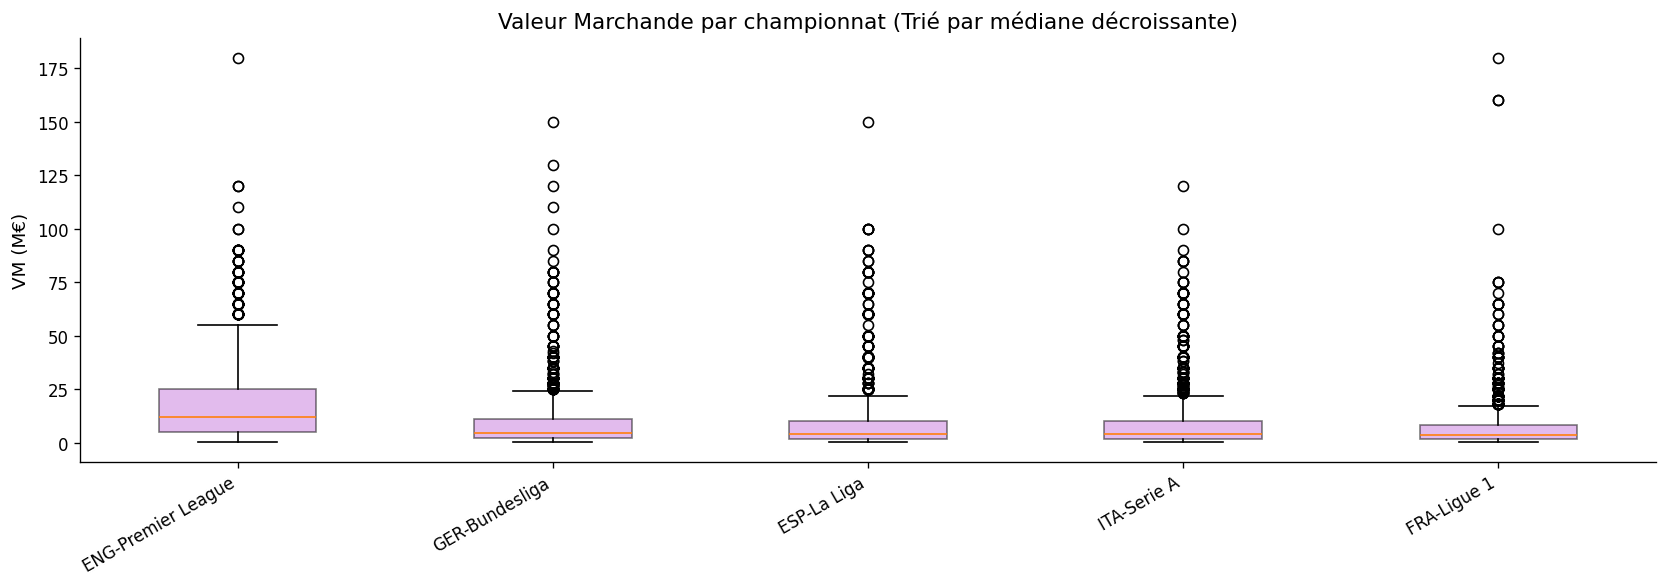

In [ ]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [ ]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            24      0.3               10   7404
  Performance_Gls           805     10.9              155   7404
  Performance_Ast           389      5.3              181   7404
               xg           440      5.9              152   7403
               xa           215      6.8               67   3149
injury_days_total           560      7.6              138   7404
  injury_nb_total           144      1.9              144   7404


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
xa                              0.482819
Performance_Gls                 0.478500
Performance_Ast                 0.459568
xg                              0.294481
injury_nb_total                 0.111816
injury_days_total               0.026712
age                            -0.156288

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


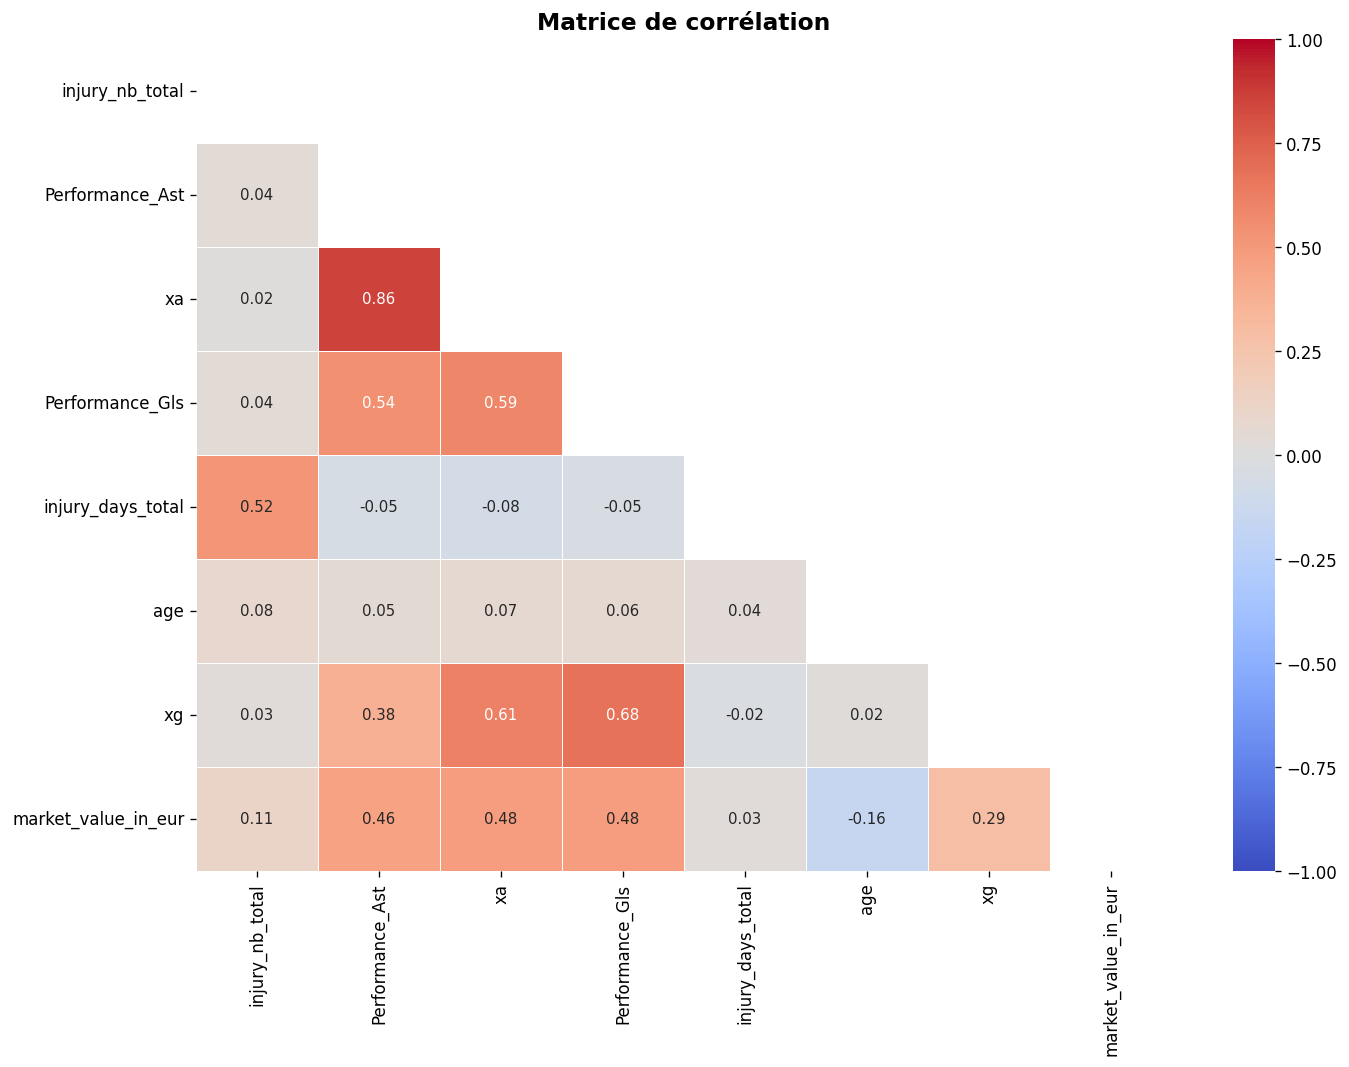


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
Team Success_onG       0.576348
log_prev_value         0.562810
xg_buildup             0.557678
Standard_Sh            0.492466
Standard_SoT           0.485281
Performance_G-PK       0.483923
xa                     0.482819
Performance_Gls        0.478500
Performance_Ast        0.459568
Playing Time_90s       0.385506
classement             0.385185
Playing Time_Starts    0.383666
Performance_Fld        0.355313
Playing Time_MP        0.354287
Team Success_PPM       0.335356
Starts_Compl           0.306113
xg                     0.294481
Subs_unSub             0.290985
Playing Time_Mn/MP     0.277455
Performance_Off        0.272054


In [ ]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


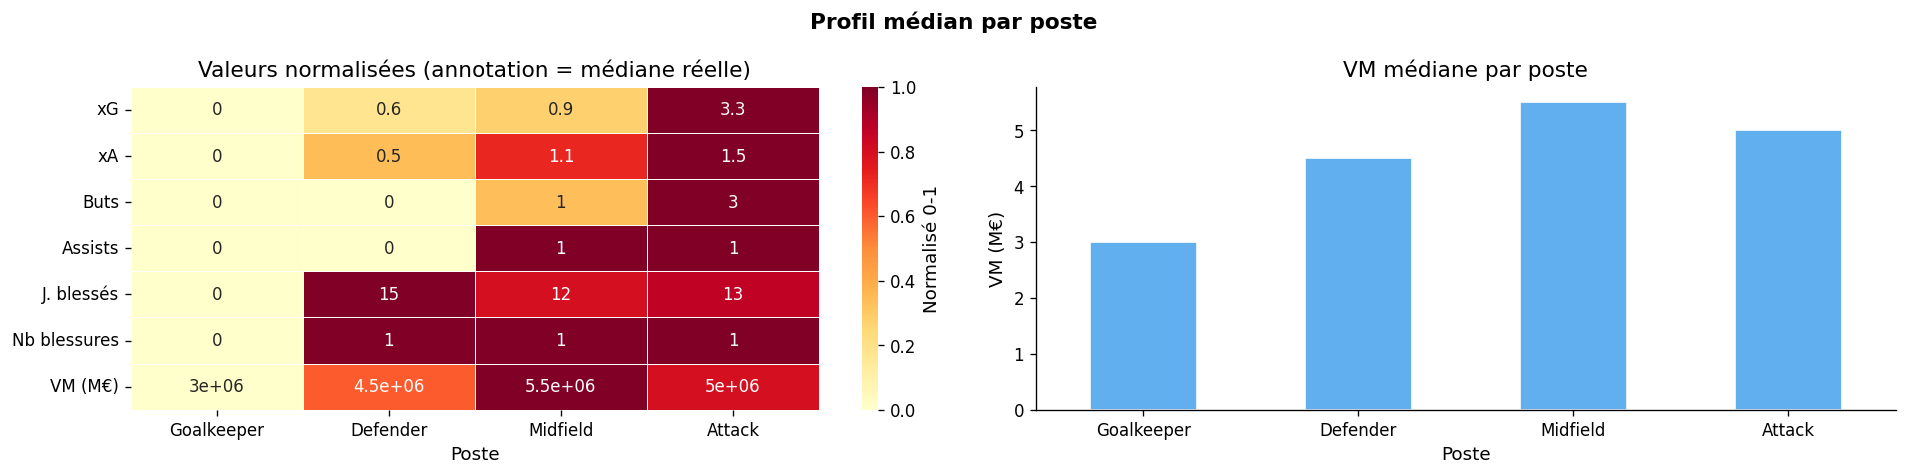

In [ ]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


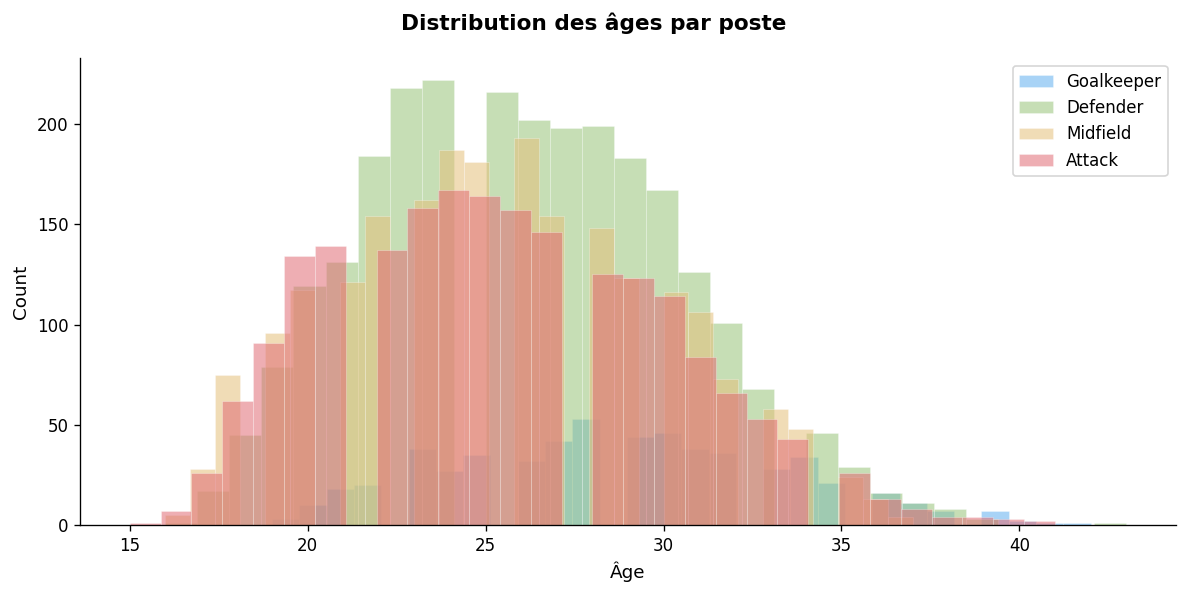


Âge médian par poste
position
Goalkeeper    29.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [ ]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


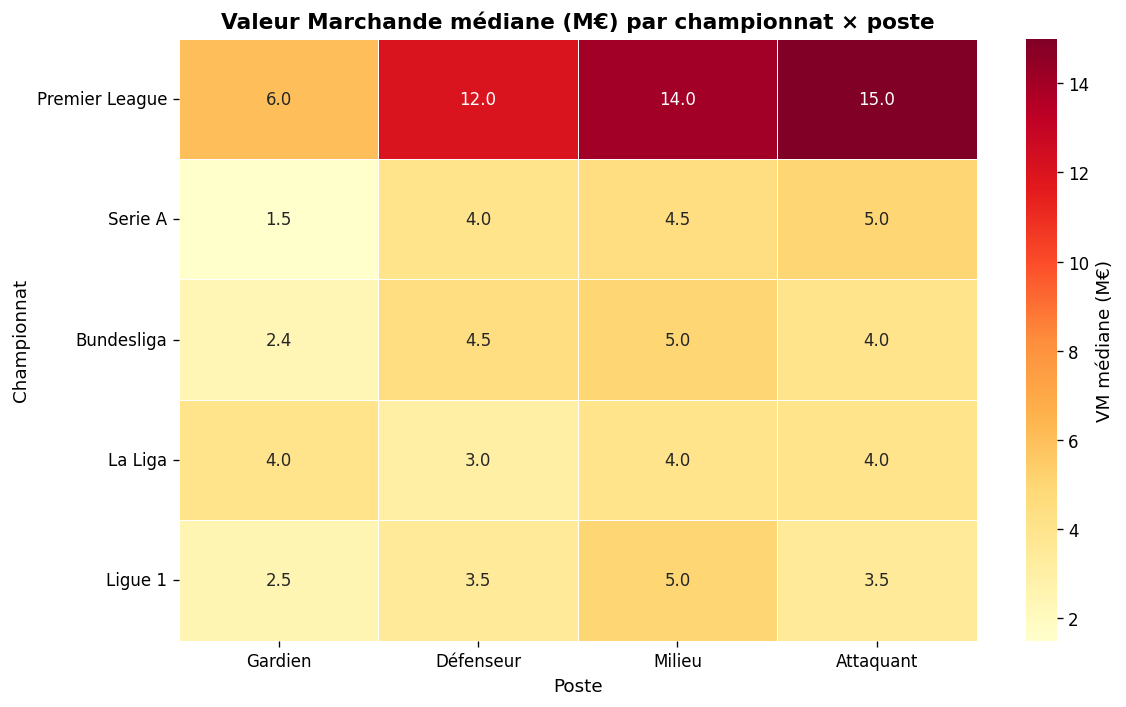

In [ ]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


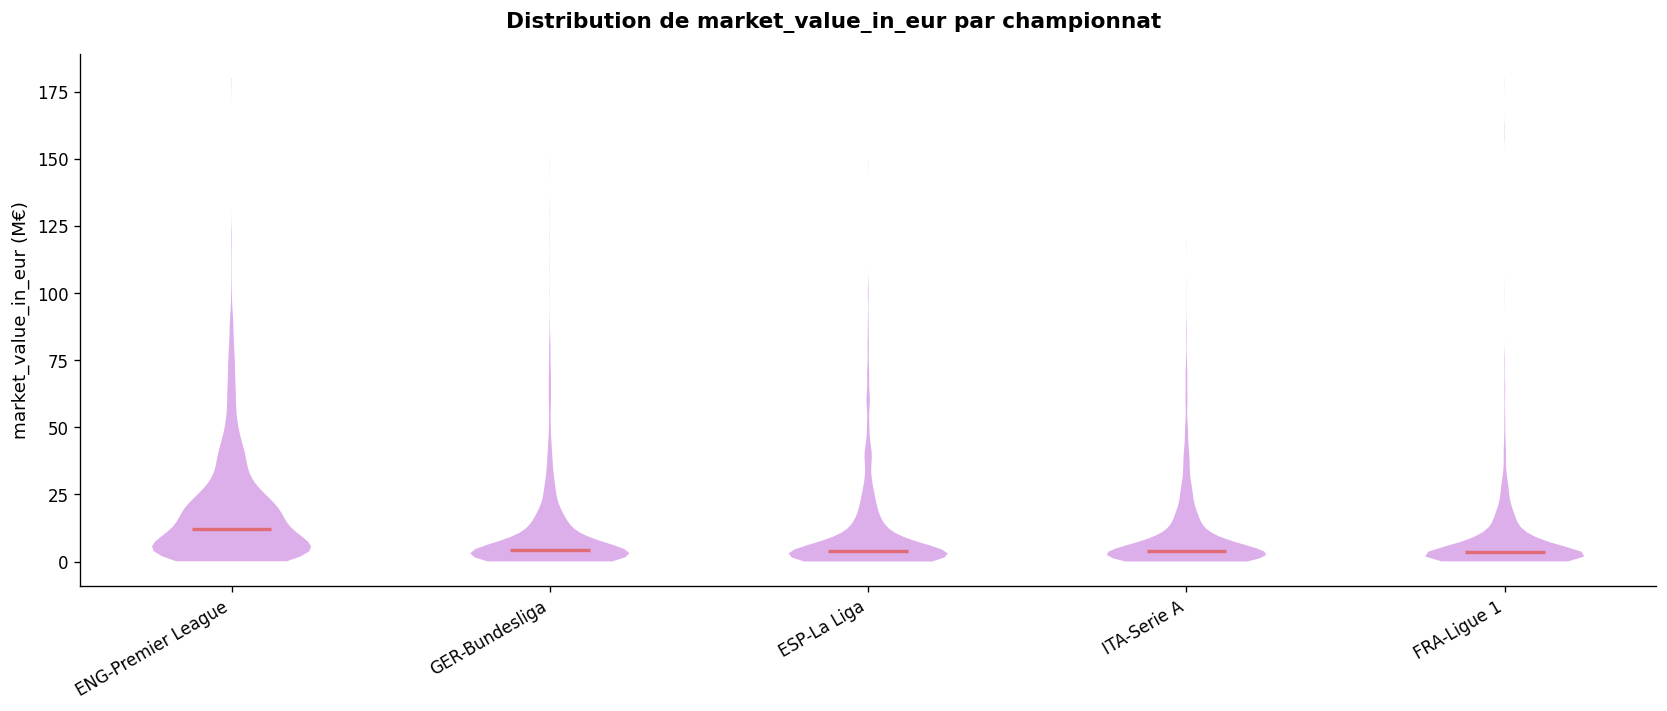

In [ ]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 22 observations

Top 20 des joueurs les plus chers
           player position  market_value_in_eur  Performance_Gls        xg  Per 90 Minutes_G+A
   Erling Haaland   Attack                180.0               36 32.761400                1.43
    Kylian Mbappé   Attack                180.0               29  2.055070                1.09
    Kylian Mbappé   Attack                160.0               27  2.055070                1.29
    Kylian Mbappé   Attack                160.0               28  2.055070                1.34
  Vinicius Júnior   Attack                150.0               10  3.188221                0.61
   Erling Haaland   Attack                150.0               22  3.452661                1.42
   Erling Haaland   Attack                130.0               27  3.452661                1.24
   Victor Osimhen   Attack                120.0               26 26.626

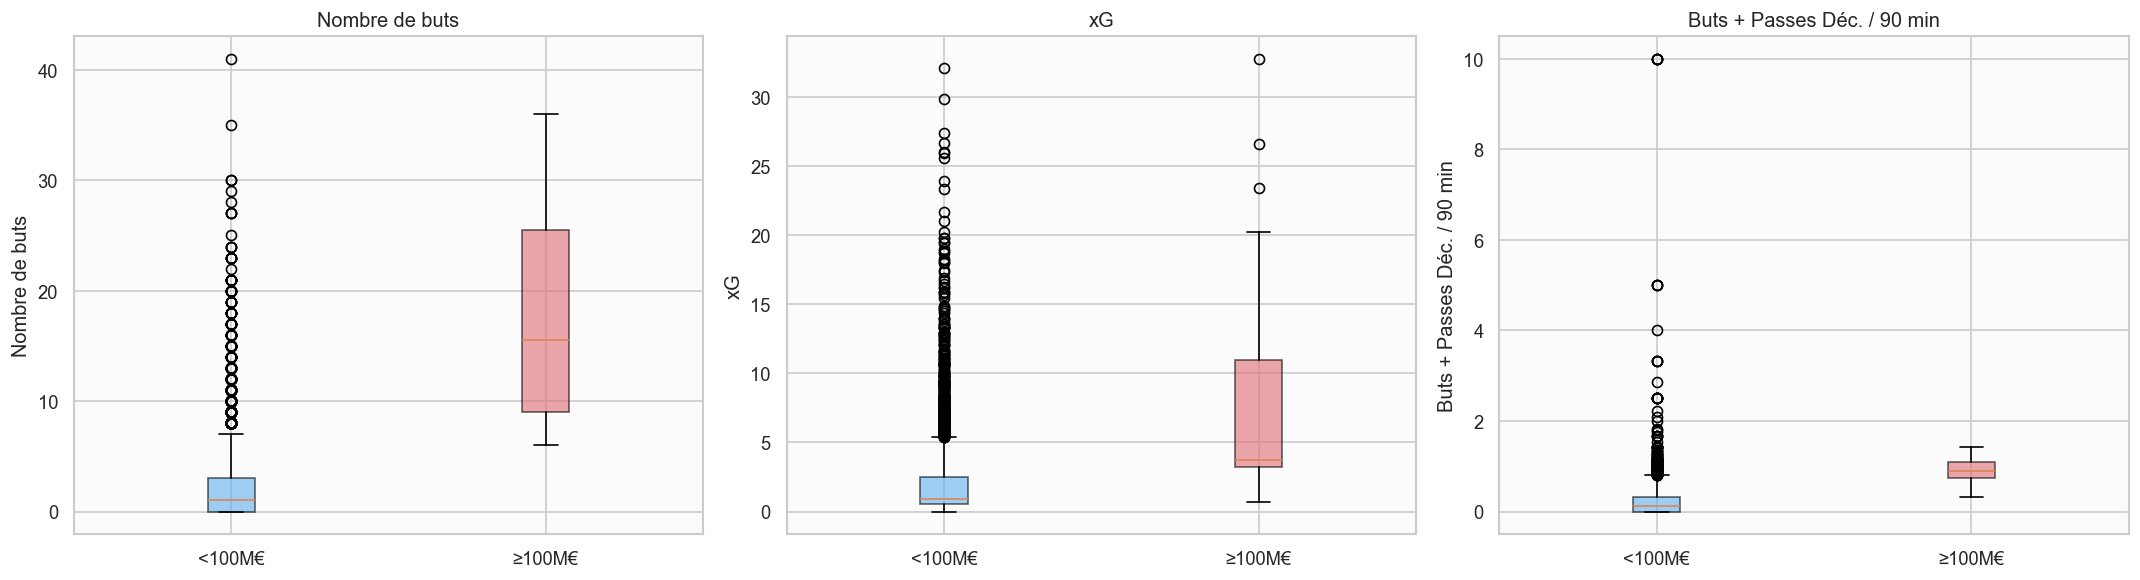

In [ ]:
df_base = df_base[df_base['position'] != 'Goalkeeper']

analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [ ]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (7404/7404 lignes analysées) :
  Cohérents (diff = 0)           : 7,084
  Diff ≤ 1 jour                  : 7,084
  Diff > 1 jour (anomalie)       : 320
  Diff max                       : 1312 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


In [ ]:
train = pd.read_csv("../data_finale/train.csv")
val = pd.read_csv("../data_finale/val.csv")
test = pd.read_csv("../data_finale/test.csv")

df = pd.concat([train, val, test], axis=0)

Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2020                  5.0     10.579836        2502
2021                  5.0     10.694078        2423
2022                  5.0     11.259419        2479
2023                  5.0     12.006643        2431
2024                  6.0     13.005044        2295

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


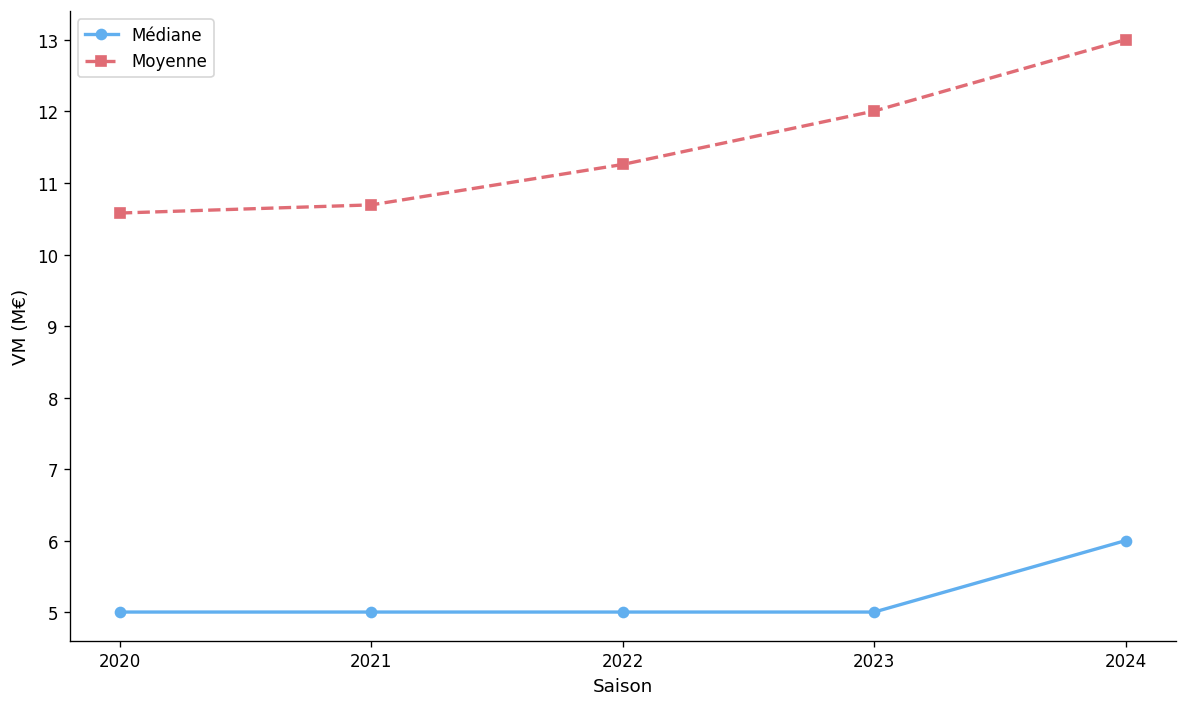

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2020,5.0,10.579836,2502
2021,5.0,10.694078,2423
2022,5.0,11.259419,2479
2023,5.0,12.006643,2431
2024,6.0,13.005044,2295


In [ ]:
analyser_evolution_temporelle_saison(df, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
7403 observations valides trouvées pour l'analyse graphique.


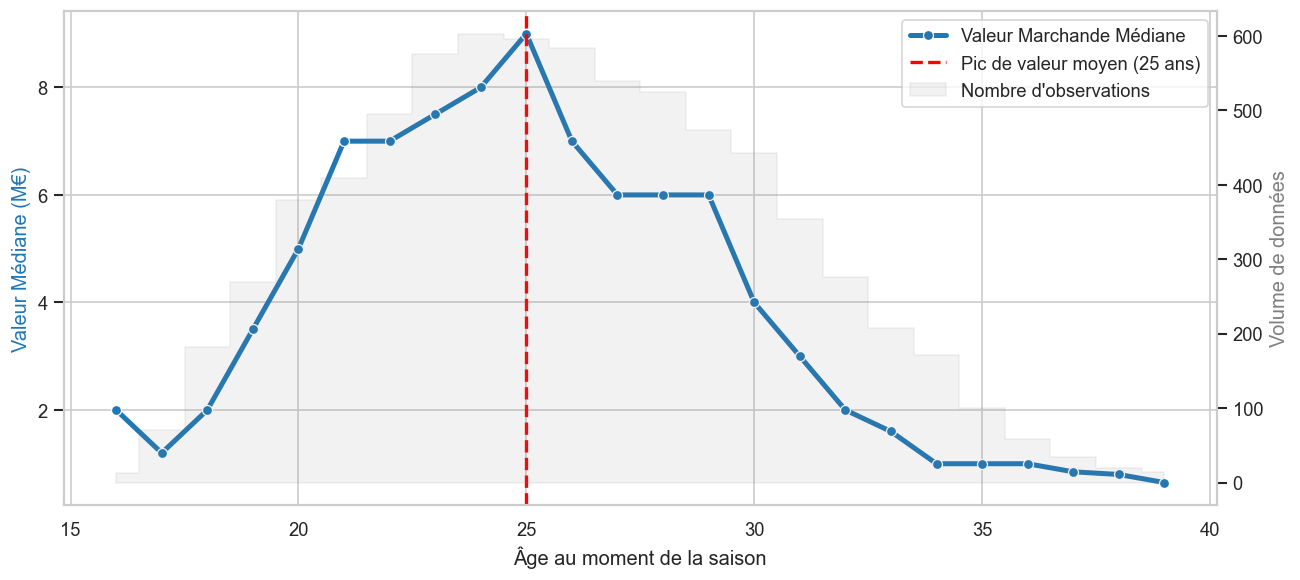


Graphique généré avec succès.


In [ ]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


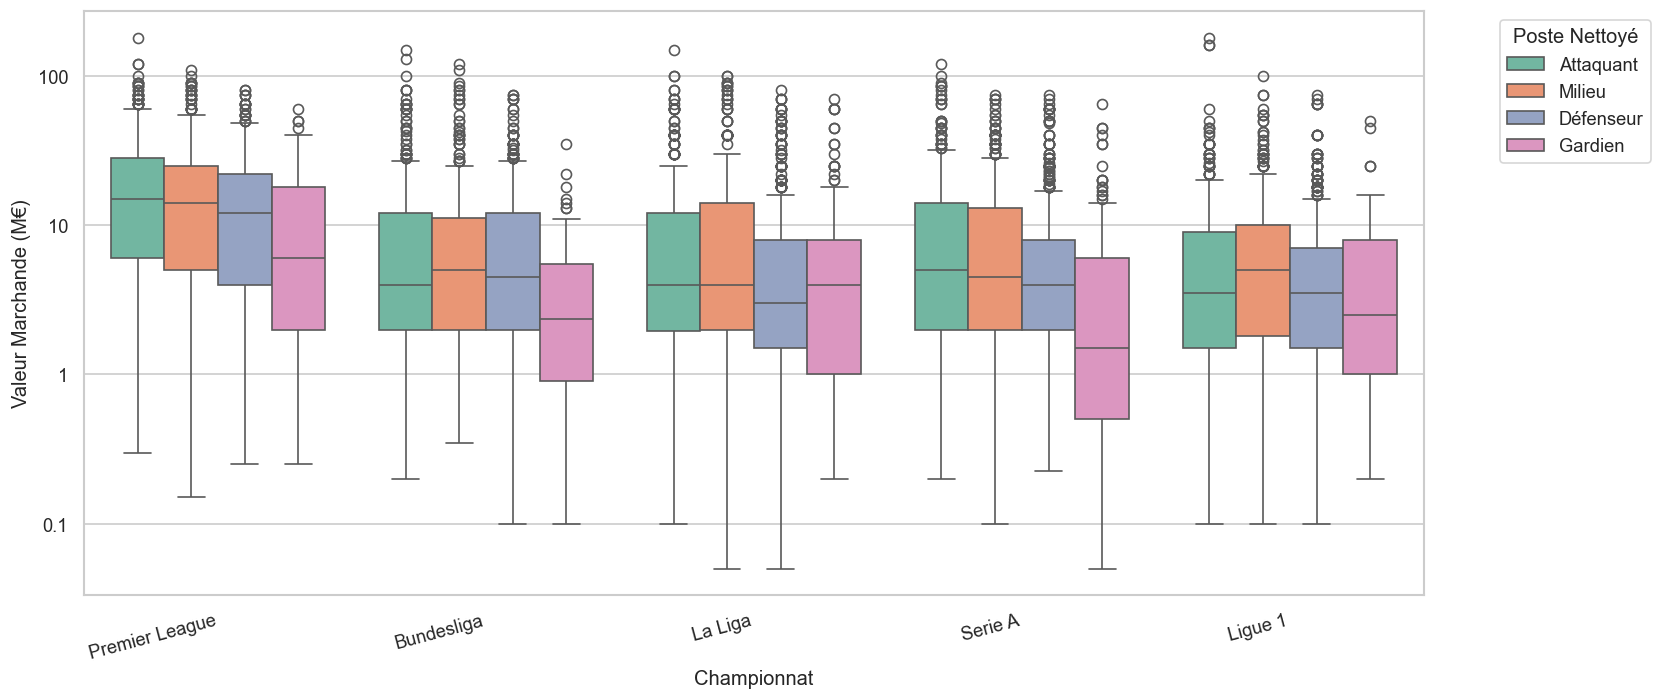


Boxplot généré avec succès.


In [ ]:
analyser_distribution_prix_ligue_poste(df_base)

In [ ]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,sub_position_Goalkeeper,pos_GK,0.997
1,Playing Time_90s,Playing Time_Starts,0.994
2,Performance_G-PK,Performance_Gls,0.977
3,pos_GK,Performance_Save%,0.971
4,Performance_PKatt,Performance_PK,0.969
5,sub_position_Goalkeeper,Performance_Save%,0.968
6,injury_musculaire_nb_m,injury_musculaire_nb_d,0.961
7,Standard_SoT,Standard_Sh,0.957
8,injury_cheville_pied_nb_m,injury_cheville_pied_nb_d,0.954
9,injury_genou_nb_m,injury_genou_nb_d,0.944


In [ ]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,sub_position_Second Striker,league_ENG-Premier League,league_ESP-La Liga,league_FRA-Ligue 1,league_GER-Bundesliga,league_ITA-Serie A,foot_both,foot_left,foot_right,log_prev_value
0,Aaron Connolly,Brighton,IRL,20,17,9,8.8,2,1,2,...,0,1,0,0,0,0,0,0,1,16.705882
1,Aaron Cresswell,West Ham United,ENG,31,36,36,35.2,0,8,0,...,0,1,0,0,0,0,0,1,0,16.648724
2,Aaron Cresswell,West Ham United,ENG,32,31,31,30.3,2,3,2,...,0,1,0,0,0,0,0,1,0,15.424949
3,Aaron Cresswell,West Ham United,ENG,33,28,24,24.8,0,1,0,...,0,1,0,0,0,0,0,1,0,14.914123
4,Aaron Hickey,Bologna,SCO,18,11,10,8.4,0,0,0,...,0,0,0,0,0,1,1,0,0,15.424949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7399,Šime Vrsaljko,Atlético Madrid,CRO,28,9,6,5.8,0,0,0,...,0,0,1,0,0,0,0,0,1,15.424949
7400,Šime Vrsaljko,Atlético Madrid,CRO,29,21,10,10.2,1,2,1,...,0,0,1,0,0,0,0,0,1,15.424949
7401,Ștefan Radu,Lazio,ROU,34,31,30,27.3,0,3,0,...,0,0,0,0,0,1,0,1,0,15.424949
7402,Ștefan Radu,Lazio,ROU,35,10,6,6.2,0,0,0,...,0,0,0,0,0,1,0,1,0,14.508658


Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


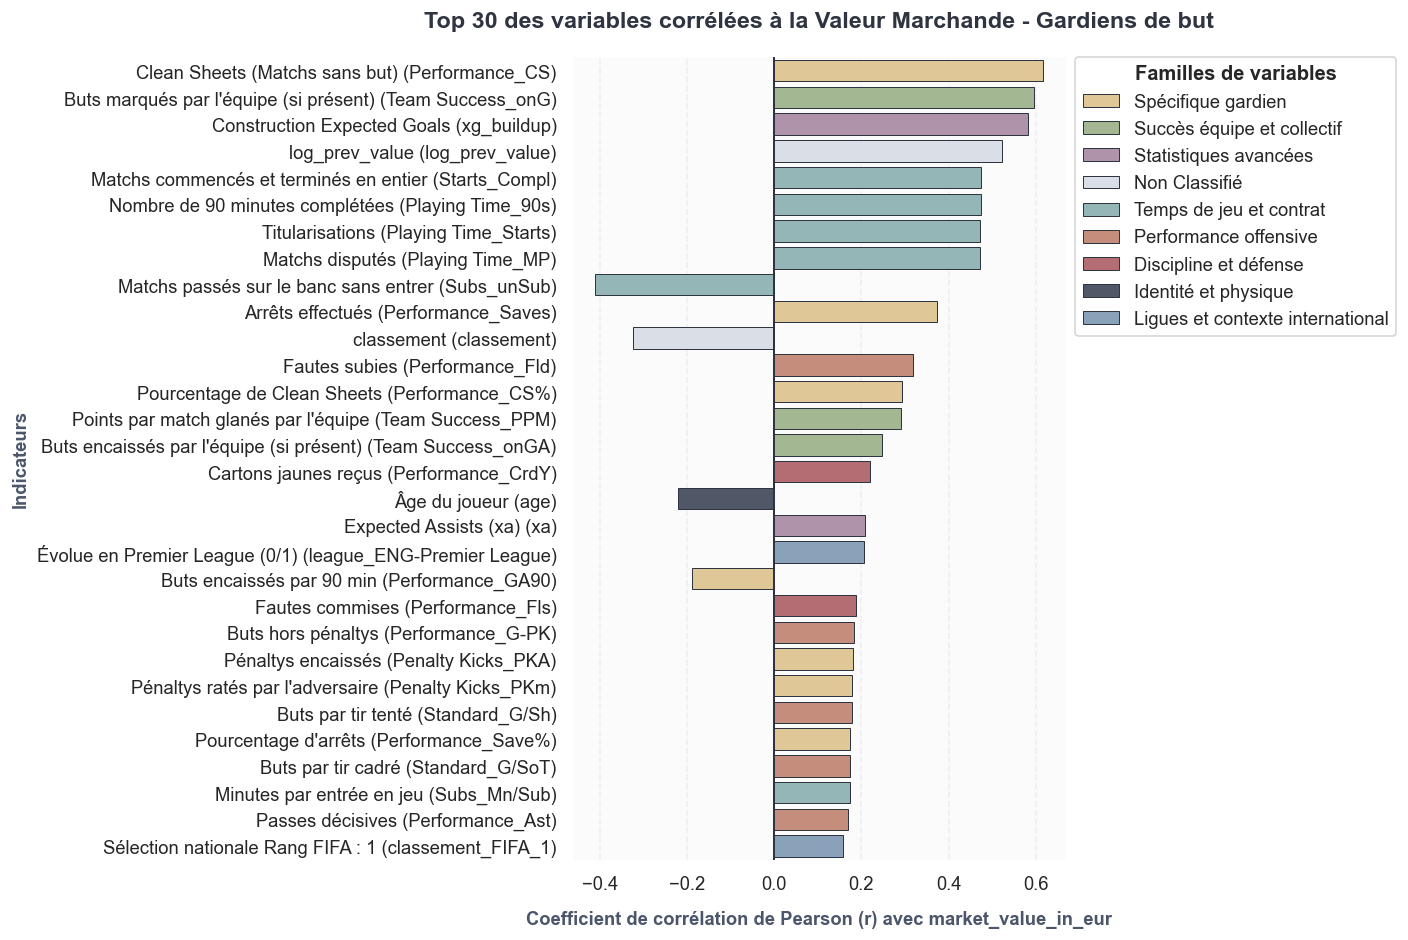

,Variable,Description,Famille,Corr_Cible_Brute
0,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.617
1,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.596
2,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.582
3,log_prev_value,log_prev_value (log_prev_value),Non Classifié,0.522
4,Starts_Compl,Matchs commencés et terminés en entier (Starts...,Temps de jeu et contrat,0.474
5,Playing Time_90s,Nombre de 90 minutes complétées (Playing Time_...,Temps de jeu et contrat,0.474
6,Playing Time_Starts,Titularisations (Playing Time_Starts),Temps de jeu et contrat,0.473
7,Playing Time_MP,Matchs disputés (Playing Time_MP),Temps de jeu et contrat,0.473
8,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.411
9,Performance_Saves,Arrêts effectués (Performance_Saves),Spécifique gardien,0.374


In [ ]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)

In [ ]:
# Filtrer sur les gardiens uniquement avant de calculer la corrélation
df_gardiens = df_base[df_base["pos_GK"] == 1]

# Calculer la corrélation pearson
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

KeyError: "['Performance_GA'] not in index"

In [ ]:
# Corrélation brute
print(df_gardiens[["Performance_GA90", "market_value_in_eur"]].corr())

# Corrélation entre les buts encaissés et la VM, mais à temps de jeu strictement égal
print("")
print("A temps de jeu égal :")
p_corr = pg.partial_corr(
    data=df_gardiens,
    x="Performance_GA",
    y="market_value_in_eur",
    covar="Playing Time_90s",
)

print(p_corr)

                     Performance_GA90  market_value_in_eur
Performance_GA90             1.000000            -0.188146
market_value_in_eur         -0.188146             1.000000

A temps de jeu égal :
           n        r            CI95         p_val
pearson  567 -0.48003  [-0.54, -0.41]  5.813400e-34


La corrélation à temps de jeu égal est bien négative : $-0.48003$, une valeur plus élevée que la corrélation de la colonne Performance_GA90 ($-0,18$). 

C'est parce que la variable Performance_GA90 (buts/90min) souffre d'un autre biais : le biais des petits échantillons.
Exemple : Un gardien remplaçant très faible entre en jeu, joue 10 minutes et prend 2 buts. Son ratio par 90 minutes explose (il monte à $18,0$ buts par match !). 

Ce genre de valeur extrême (outlier) vient "bruiter" et affaiblir la corrélation Pearson.